In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [29]:
from google.colab import files
uploaded = files.upload()

Saving house_price_dataset.csv to house_price_dataset (1).csv


In [30]:
df = pd.read_csv("house_price_dataset.csv")
df.head()

,Area_sqft,Bedrooms,Bathrooms,Parking,House_Age,Location_Rating,Distance_City_km,Price
0,3974,4,1,0,9,4,26,19053000
1,1660,5,4,0,5,3,21,9640000
2,2094,1,1,2,24,7,18,10233000
3,1930,5,3,2,29,8,13,11245000
4,1895,5,1,3,17,4,11,10497500


In [31]:
print("Shape of Dataset:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nDataset Information:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

Shape of Dataset:
(100, 8)

Columns:
Index(['Area_sqft', 'Bedrooms', 'Bathrooms', 'Parking', 'House_Age',
       'Location_Rating', 'Distance_City_km', 'Price'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Area_sqft         100 non-null    int64
 1   Bedrooms          100 non-null    int64
 2   Bathrooms         100 non-null    int64
 3   Parking           100 non-null    int64
 4   House_Age         100 non-null    int64
 5   Location_Rating   100 non-null    int64
 6   Distance_City_km  100 non-null    int64
 7   Price             100 non-null    int64
dtypes: int64(8)
memory usage: 6.4 KB
None

Statistical Summary:
         Area_sqft    Bedrooms   Bathrooms     Parking   House_Age  \
count   100.000000  100.000000  100.000000  100.000000  100.000000   
mean   2472.660000    2.910000    2.

In [32]:
print(df.isnull().sum())

Area_sqft           0
Bedrooms            0
Bathrooms           0
Parking             0
House_Age           0
Location_Rating     0
Distance_City_km    0
Price               0
dtype: int64


In [33]:
df.fillna(df.mean(numeric_only=True), inplace=True)
print(df.isnull().sum())

Area_sqft           0
Bedrooms            0
Bathrooms           0
Parking             0
House_Age           0
Location_Rating     0
Distance_City_km    0
Price               0
dtype: int64


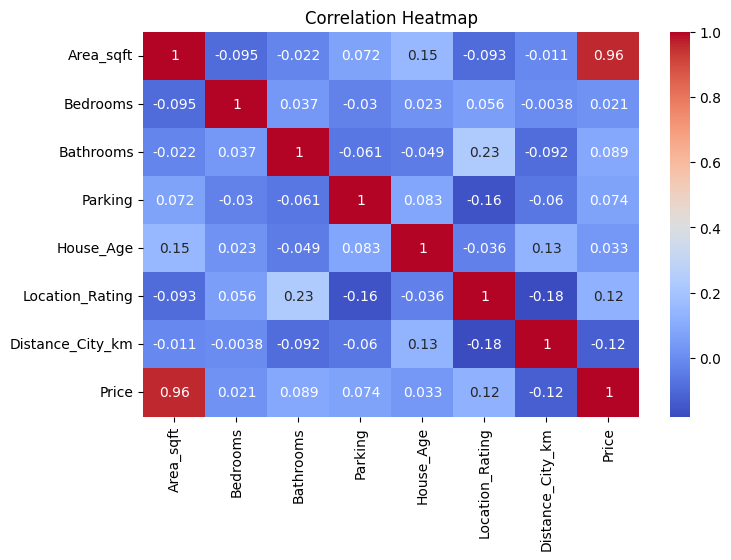

In [34]:
plt.figure(figsize=(8,5))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.show()

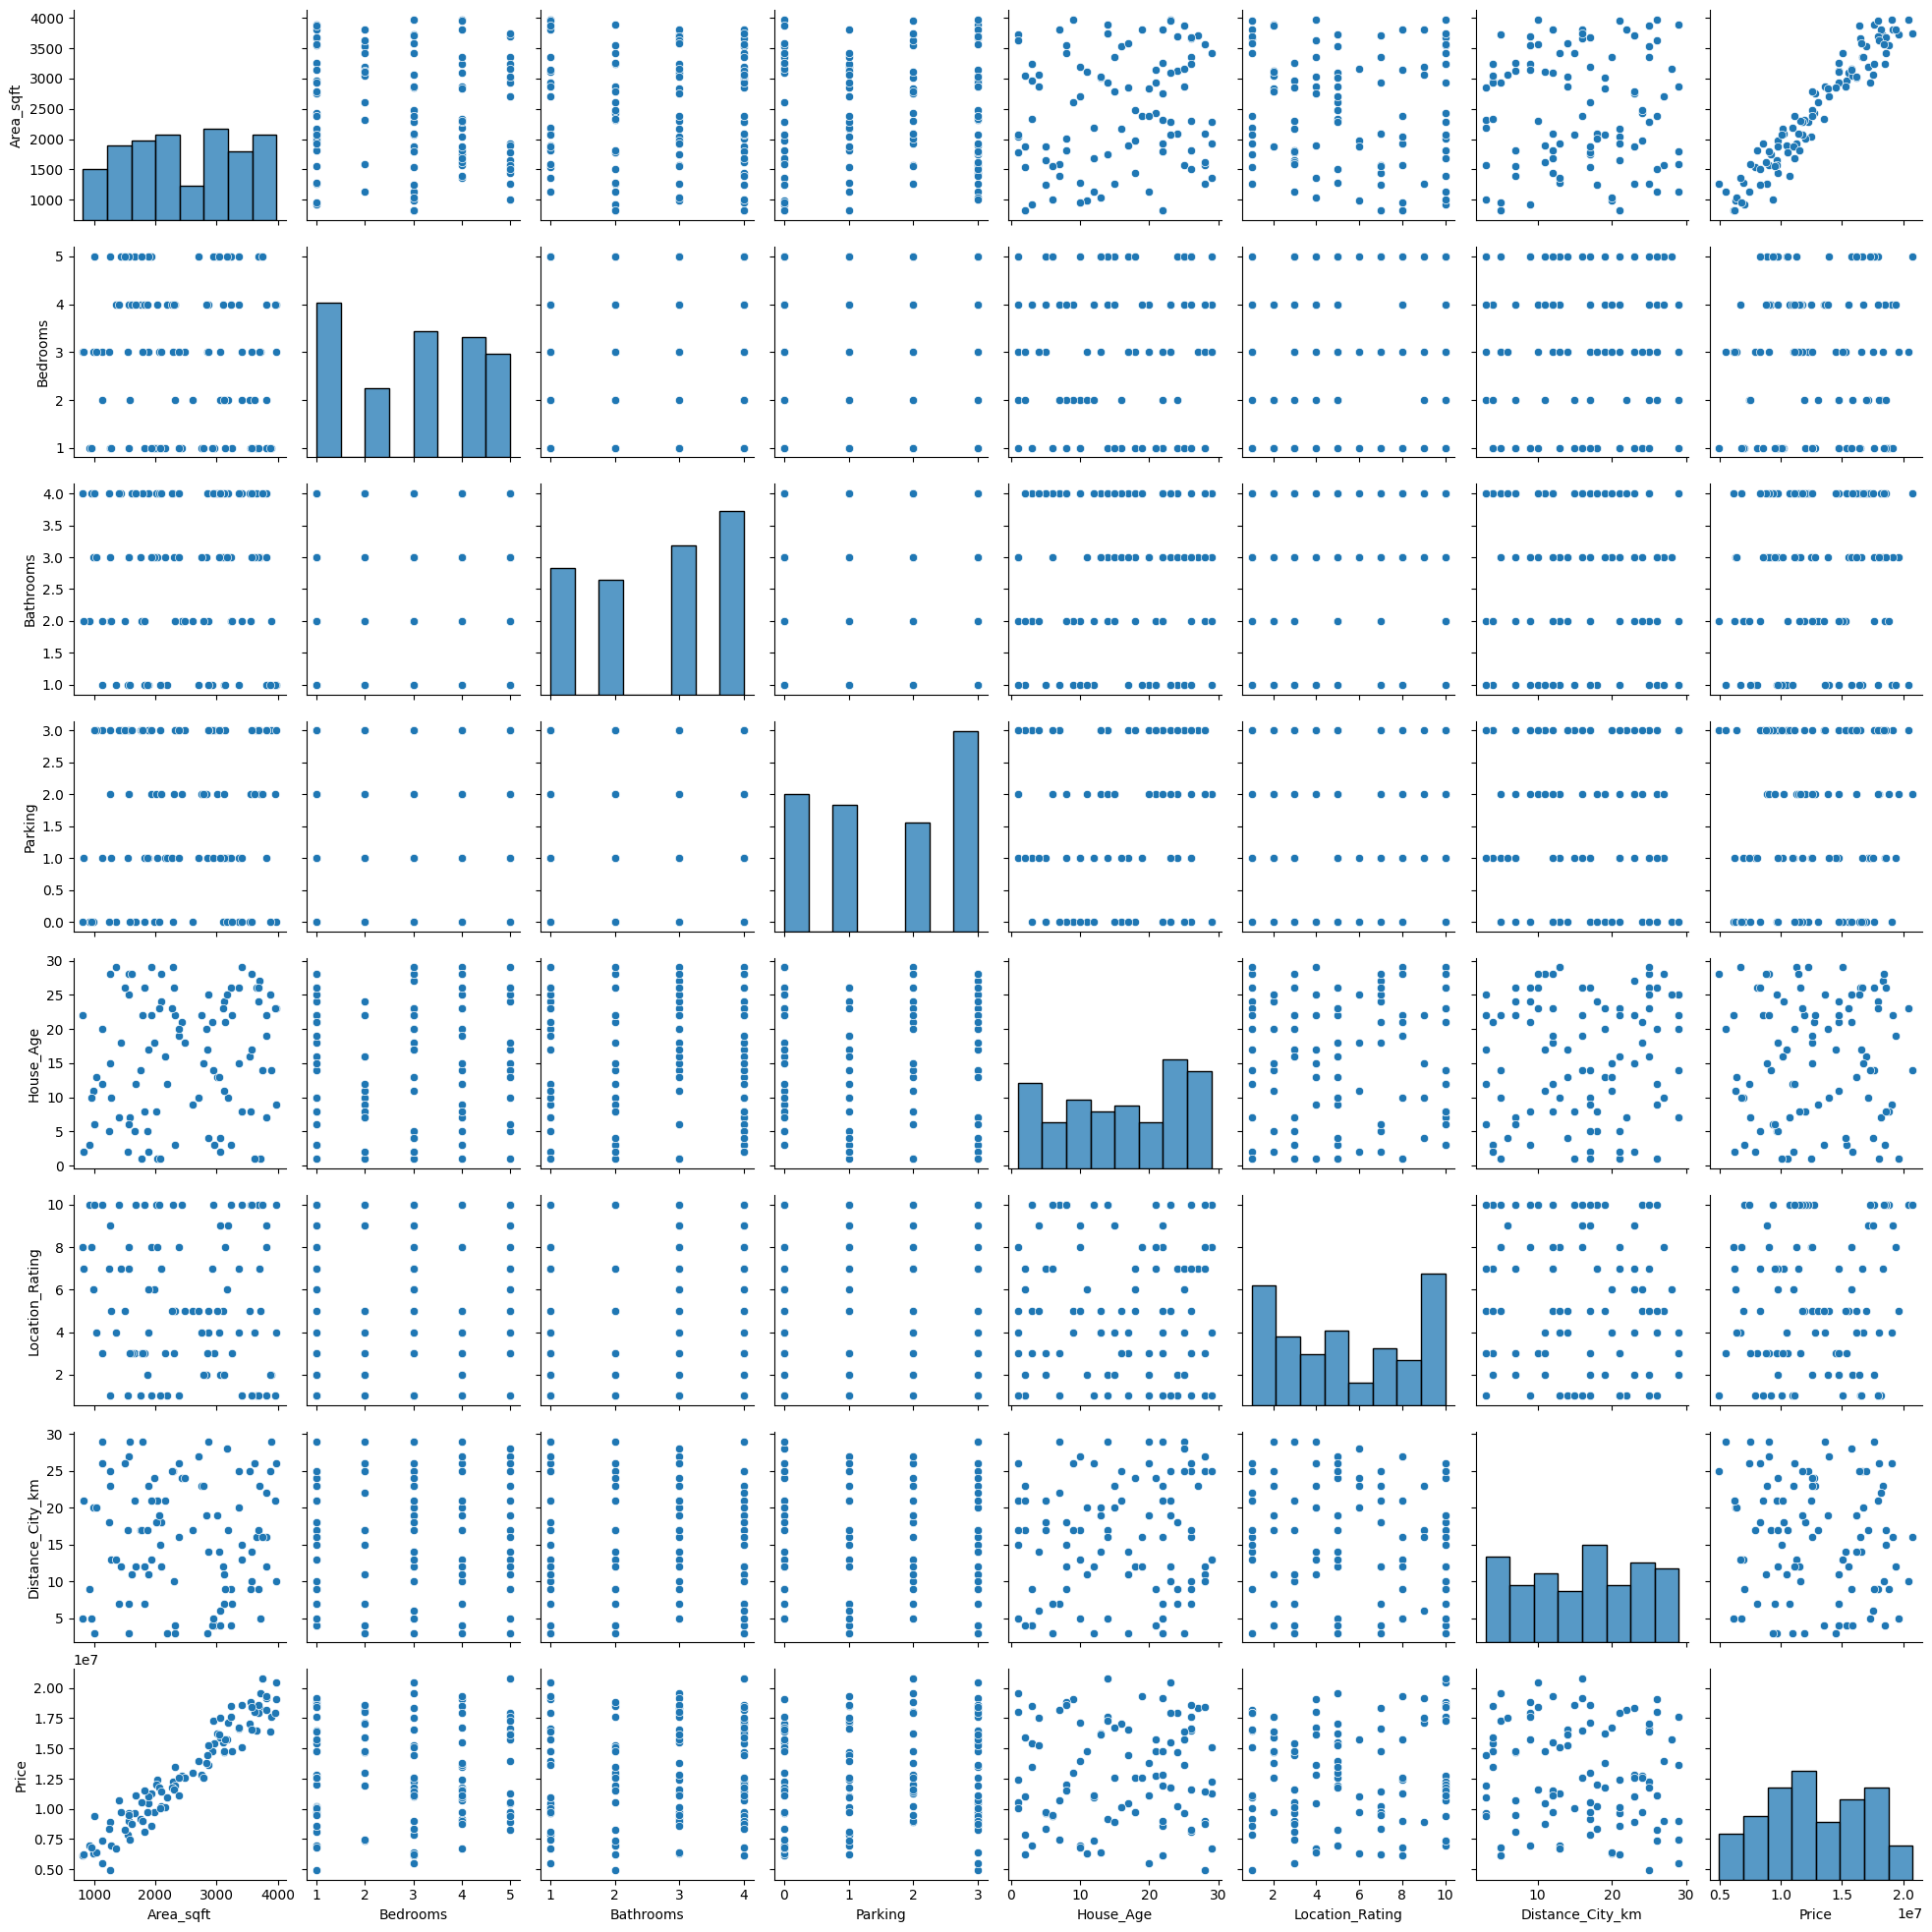

In [35]:
sns.pairplot(df)
plt.show()

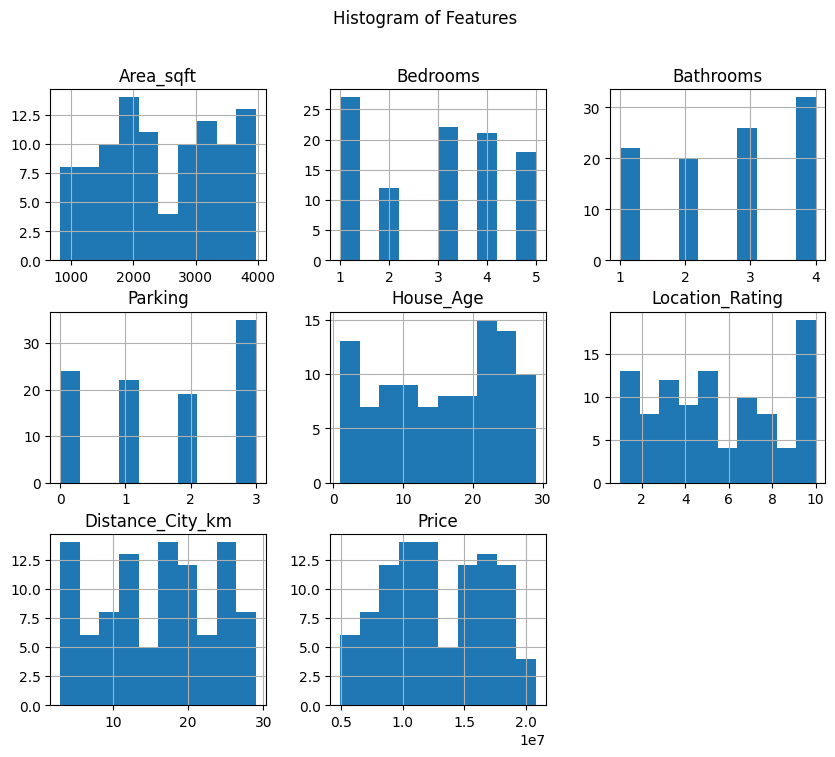

In [36]:
df.hist(figsize=(10,8))
plt.suptitle("Histogram of Features")
plt.show()

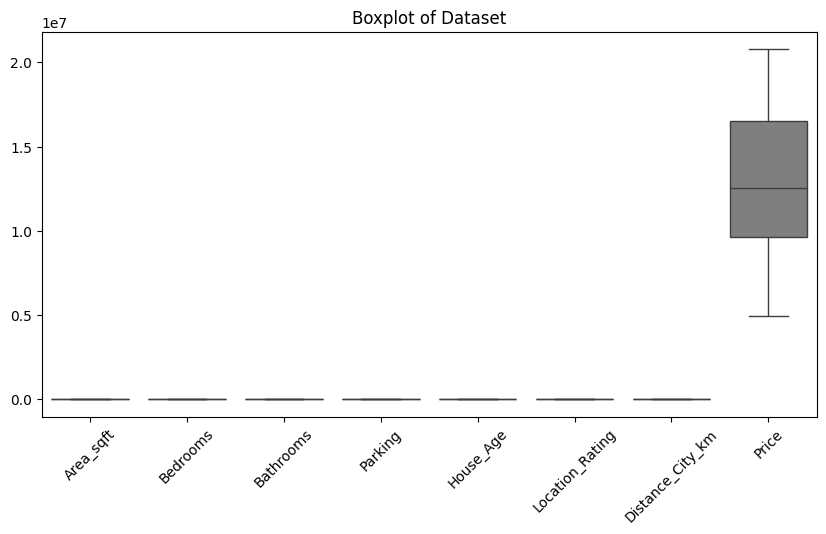

In [37]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.title("Boxplot of Dataset")
plt.show()

In [38]:
X = df.drop("Price", axis=1)
y = df["Price"]
print(X.head())
print(y.head())

   Area_sqft  Bedrooms  Bathrooms  Parking  House_Age  Location_Rating  \
0       3974         4          1        0          9                4   
1       1660         5          4        0          5                3   
2       2094         1          1        2         24                7   
3       1930         5          3        2         29                8   
4       1895         5          1        3         17                4   

   Distance_City_km  
0                26  
1                21  
2                18  
3                13  
4                11  
0    19053000
1     9640000
2    10233000
3    11245000
4    10497500
Name: Price, dtype: int64


In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [40]:
model = LinearRegression()
model.fit(X_train, y_train)
print("Model Trained Successfully")

Model Trained Successfully


In [41]:
y_pred = model.predict(X_test)
print(y_pred)

[ 9364500. 10690000. 17954000. 18595500. 11781500. 19142500. 12027500.
 16576500.  5515000. 19053000. 17149500. 18328000. 16428500. 16661000.
 11512000. 10497500.  8550500. 11600000. 14737500.  6943000.]


In [42]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)

MAE : 2.514570951461792e-09
MSE : 8.153200337090994e-18
RMSE : 2.855380944303403e-09
R2 Score : 1.0


In [43]:
comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

comparison.head(10)

,Actual Price,Predicted Price
0,9364500,9364500.0
1,10690000,10690000.0
2,17954000,17954000.0
3,18595500,18595500.0
4,11781500,11781500.0
5,19142500,19142500.0
6,12027500,12027500.0
7,16576500,16576500.0
8,5515000,5515000.0
9,19053000,19053000.0


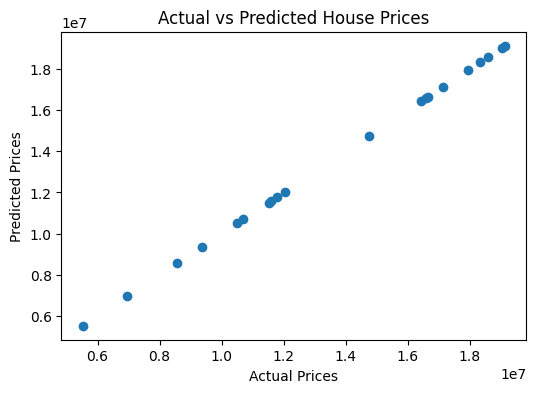

In [47]:
plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")
plt.show()

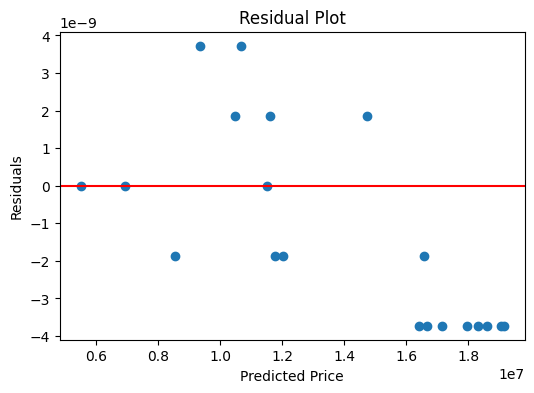

In [48]:
residuals = y_test - y_pred
plt.figure(figsize=(6,4))
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='red')
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

In [45]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})
importance

,Feature,Coefficient
0,Area_sqft,4500.0
1,Bedrooms,300000.0
2,Bathrooms,200000.0
3,Parking,150000.0
4,House_Age,-50000.0
5,Location_Rating,250000.0
6,Distance_City_km,-30000.0


In [46]:
new_house = X.iloc[[0]].values
prediction = model.predict(new_house)
print("Predicted House Price :", prediction[0])

Predicted House Price : 19053000.000000004


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
